# Mathemagicland 2D Random Walk Solution

This notebook simulates the 2D walk model from mathemagicland's video solution:
[https://www.instagram.com/mathemagiclandinsta/reel/DW2BveQklDj/](https://www.instagram.com/mathemagiclandinsta/reel/DW2BveQklDj/)

Model:
- Start at (0, 0)
- At each step choose one of 0, 90, 180, 270 degrees uniformly
- Take a unit step in that direction
- Stop when the walk first returns to the origin after leaving it

All files are saved in `outputs/mathemagicland_solution/`.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils import (
    ensure_output_dirs,
    plot_histogram,
    plot_overlay_2d,
    plot_single_walk_2d,
    save_2d_path_json,
    save_summary_csv,
    simulate_cardinal_walk_2d,
)

# Configuration
RANDOM_SEED = 42
N_TRIALS = 10
MAX_STEPS = 20_000
NOTEBOOK_DIR = Path(".")
OUTPUT_DIR, PATHS_DIR = ensure_output_dirs(
    NOTEBOOK_DIR / "outputs" / "mathemagicland_solution"
)

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(RANDOM_SEED)

print(f"Working directory: {NOTEBOOK_DIR.resolve()}")
print(f"Output directory:  {OUTPUT_DIR.resolve()}")

Working directory: /home/manpazito/projects/fun_mini_sims/random_walks
Output directory:  /home/manpazito/projects/fun_mini_sims/random_walks/outputs/mathemagicland_solution


## Mathematical Description

Each step is chosen uniformly from the four cardinal vectors:
- (1, 0), (0, 1), (-1, 0), (0, -1)

If S_n is position at step n, then S_0 = (0,0) and S_n = S_{n-1} + V_n.

We stop at the first return time:
`T = min{ n >= 1 : S_n = (0,0) }`.

A `MAX_STEPS` cap marks unfinished runs as censored.

In [2]:
def make_trial_record(walk: Dict[str, object], trial_index: int) -> Dict[str, object]:
    return {
        "trial_index": trial_index,
        "steps_until_stop": walk["steps_until_stop"],
        "return_time": walk["return_time"],
        "returned_to_origin": walk["returned_to_origin"],
        "censored": walk["censored"],
        "max_distance": walk["max_distance"],
        "max_manhattan": walk["max_manhattan"],
        "bbox_width": walk["bbox_width"],
        "bbox_height": walk["bbox_height"],
        "bbox_area": walk["bbox_area"],
        "final_x": walk["final_x"],
        "final_y": walk["final_y"],
    }

## Single Example Walk

Simulate one 2D path and mark origin and stop point.

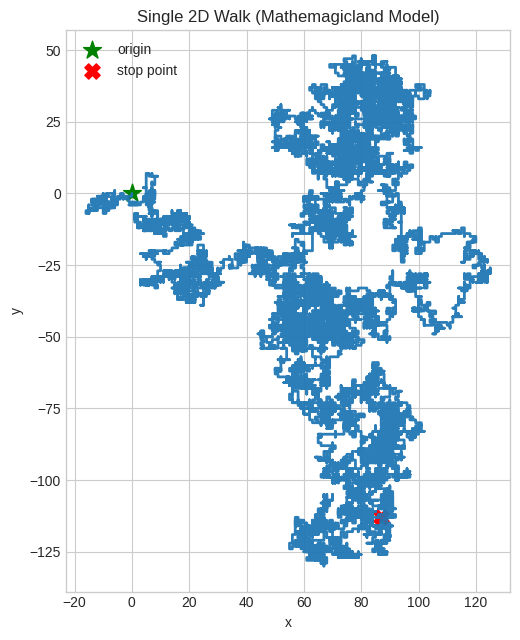

Single walk summary:
  steps_until_stop:   20000
  returned_to_origin: False
  max_distance:       154.263
  bbox (w x h):       141 x 178
  saved plot:         outputs/mathemagicland_solution/single_walk.png


In [3]:
single_walk = simulate_cardinal_walk_2d(rng=rng, max_steps=MAX_STEPS)

single_walk_plot_path = OUTPUT_DIR / "single_walk.png"
plot_single_walk_2d(
    xs=single_walk["xs"],
    ys=single_walk["ys"],
    out_path=single_walk_plot_path,
    title="Single 2D Walk (Mathemagicland Model)",
)

print("Single walk summary:")
print(f"  steps_until_stop:   {single_walk['steps_until_stop']}")
print(f"  returned_to_origin: {single_walk['returned_to_origin']}")
print(f"  max_distance:       {single_walk['max_distance']:.3f}")
print(
    f"  bbox (w x h):       {single_walk['bbox_width']} x {single_walk['bbox_height']}"
)
print(f"  saved plot:         {single_walk_plot_path}")

## Monte Carlo Simulation

Run many independent trials and save summary + per-trial paths.

In [4]:
trial_records: List[Dict[str, object]] = []
all_paths: List[Tuple[List[int], List[int]]] = []

for trial_idx in range(N_TRIALS):
    walk = simulate_cardinal_walk_2d(rng=rng, max_steps=MAX_STEPS)
    all_paths.append((walk["xs"], walk["ys"]))
    save_2d_path_json(walk["xs"], walk["ys"], trial_idx, PATHS_DIR)
    trial_records.append(make_trial_record(walk, trial_idx))

summary_df = pd.DataFrame(trial_records)
summary_csv_path = save_summary_csv(summary_df, OUTPUT_DIR / "summary.csv")

completed = summary_df[~summary_df["censored"]]

print(f"Trials run:                {N_TRIALS}")
print(f"Completed returns:         {len(completed)}")
print(f"Censored trials:           {int(summary_df['censored'].sum())}")
if len(completed):
    print(f"Mean return time:          {completed['return_time'].mean():.3f}")
print(f"Mean max distance:         {summary_df['max_distance'].mean():.3f}")
print(f"Saved summary CSV:         {summary_csv_path}")

summary_df.head()

Trials run:                10
Completed returns:         9
Censored trials:           1
Mean return time:          635.556
Mean max distance:         23.950
Saved summary CSV:         outputs/mathemagicland_solution/summary.csv


,trial_index,steps_until_stop,return_time,returned_to_origin,censored,max_distance,max_manhattan,bbox_width,bbox_height,bbox_area,final_x,final_y
0,0,2,2.0,True,False,1.0,1,1,0,0,0,0
1,1,2,2.0,True,False,1.0,1,0,1,0,0,0
2,2,2,2.0,True,False,1.0,1,0,1,0,0,0
3,3,8,8.0,True,False,2.0,2,1,2,2,0,0
4,4,2,2.0,True,False,1.0,1,1,0,0,0,0


## Visualization of Monte Carlo Results

Plot return-time and max-distance histograms.

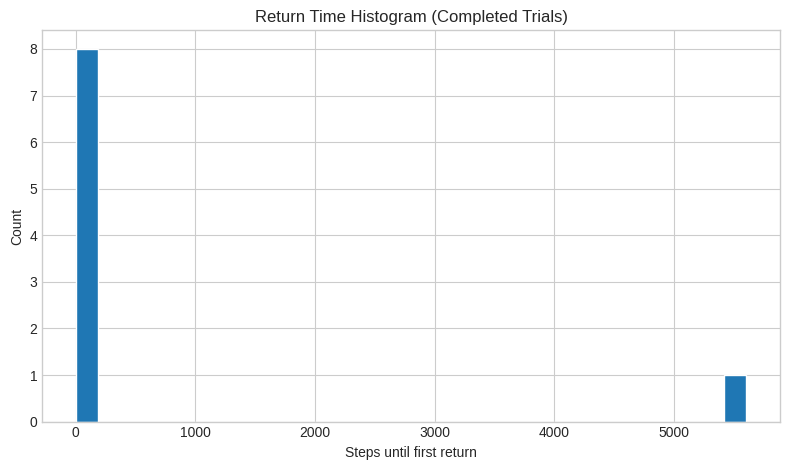

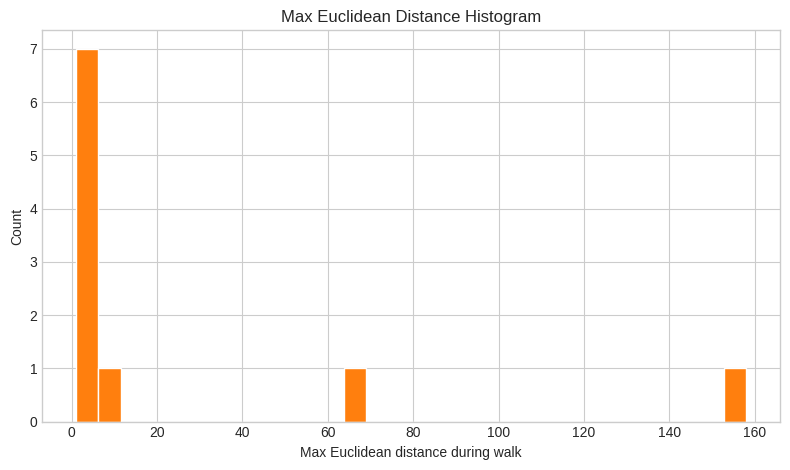

Saved: outputs/mathemagicland_solution/return_time_histogram.png
Saved: outputs/mathemagicland_solution/max_distance_histogram.png


In [5]:
completed_return_times = summary_df.loc[~summary_df["censored"], "return_time"]

return_hist_path = OUTPUT_DIR / "return_time_histogram.png"
max_dist_hist_path = OUTPUT_DIR / "max_distance_histogram.png"

plot_histogram(
    values=completed_return_times,
    out_path=return_hist_path,
    title="Return Time Histogram (Completed Trials)",
    xlabel="Steps until first return",
    color="tab:blue",
)

plot_histogram(
    values=summary_df["max_distance"],
    out_path=max_dist_hist_path,
    title="Max Euclidean Distance Histogram",
    xlabel="Max Euclidean distance during walk",
    color="tab:orange",
)

print(f"Saved: {return_hist_path}")
print(f"Saved: {max_dist_hist_path}")

## Final Overlay Plot

Overlay all 2D paths with transparency and equal axis scaling.

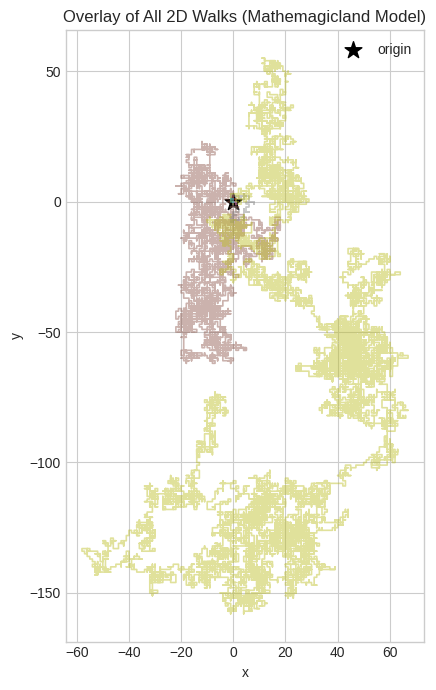

Saved: outputs/mathemagicland_solution/overlay_walks.png


In [6]:
overlay_path = OUTPUT_DIR / "overlay_walks.png"
plot_overlay_2d(
    all_paths=all_paths,
    out_path=overlay_path,
    title="Overlay of All 2D Walks (Mathemagicland Model)",
)
print(f"Saved: {overlay_path}")